In [1]:
from sklearn.datasets import make_classification
import numpy as np

In [56]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1,
                           random_state=41, hypercube=False, class_sep=10)

In [7]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

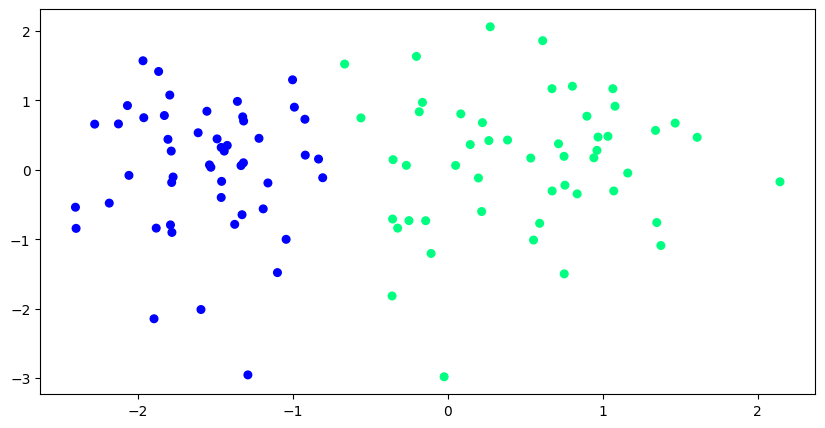

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=30)
plt.show()

In [4]:
#def step function
def step(z):
    return 1 if z>=0 else 0

In [27]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    w = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(X.shape[0])
        y_hat = step(np.dot(X[j], w))
        w = w + lr*(y[j] - y_hat)*X[j]
    return w[0], w[1:]

In [28]:
intercept_, coef_ = perceptron(X, y)

In [29]:
print(intercept_)
print(coef_)

1.0
[1.35394428 0.17072334]


Ax+By+C = 0 => this is the general equation.

m = -(A/B)

b = -(C/B)

In [30]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [32]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

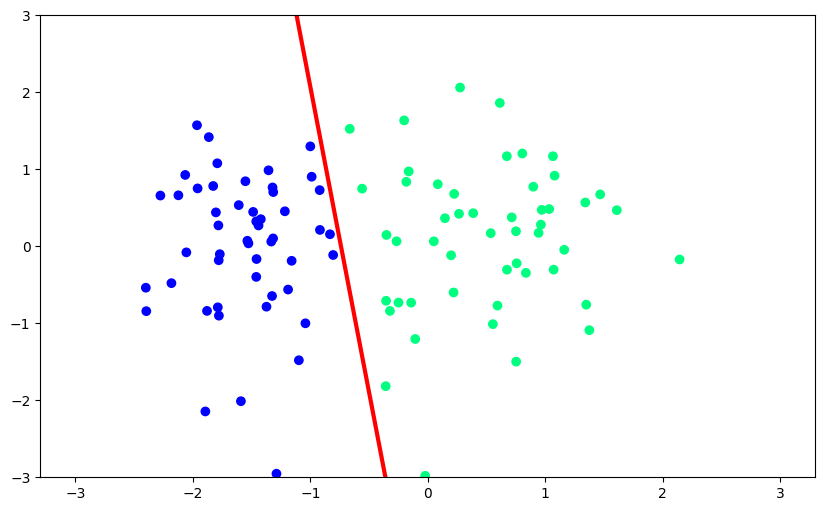

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter')
plt.ylim(-3, 3)
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
lor = LogisticRegression()
lor.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [46]:
lor.intercept_[0]

np.float64(2.251066355210435)

In [47]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_[0]/lor.coef_[0][1])

In [48]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m * x_input1 + b

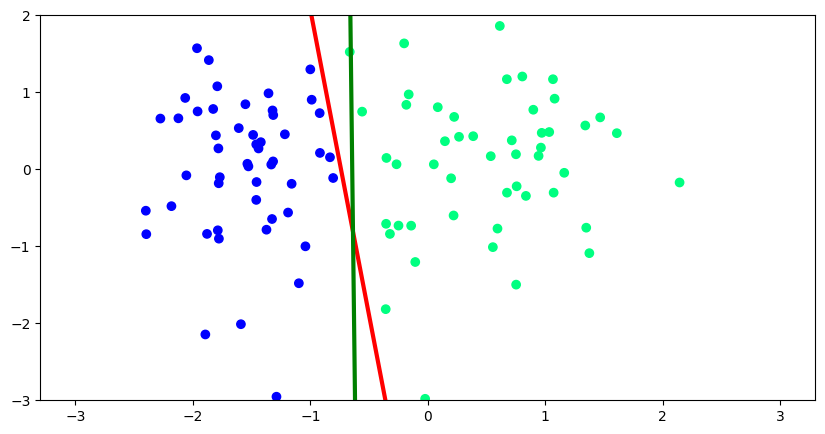

In [49]:
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.plot(x_input, y_input, color='red', linewidth=3)
plt.plot(x_input1, y_input1, color='green', linewidth=3)
plt.ylim(-3, 2)
plt.show()

In [73]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [74]:
def Perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(X.shape[0])
        y_hat = sigmoid(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]
    return weights[0], weights[1:]

In [75]:
intercept, coef = Perceptron(X, y)

In [80]:
m = -(coef[0]/coef[1])
b = -(intercept/coef[1])

In [81]:
x_input2 = np.linspace(-3, 3, 100)
y_input2 = m * x_input2 + b

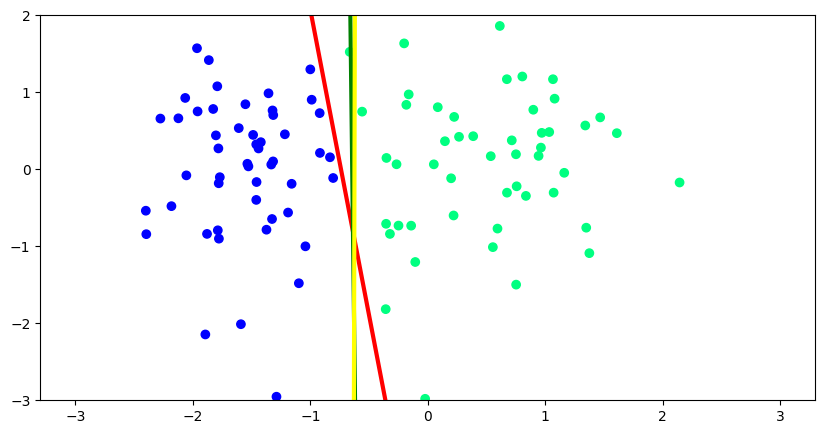

In [82]:
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.plot(x_input1, y_input1, color = 'green', linewidth = 3)
plt.plot(x_input2, y_input2, color = 'yellow', linewidth = 3)
plt.ylim(-3, 2)
plt.show()

In [85]:
def perceptron_(X, y):
    m = []
    b = []
    X = np.insert(X, 0, 1, axis=1)
    weight = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(X.shape[0])
        y_hat = step(np.dot(X[j], weight))
        weight = weight + lr * (y[j] - y_hat) * X[j]
        m.append(-(weight[1]/weight[2]))
        b.append(-(weight[0]/weight[2]))
    return m, b

In [86]:
m, b = perceptron_(X, y)

In [87]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [98]:
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
plt.show()

<IPython.core.display.Javascript object>

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
